# Heart Disease UCI — EDA & inference walkthrough

Interactive companion to the pipeline scripts. The canonical, tested implementations live in `src/` (`src.eda`, `src.train`); this notebook explores the data and demonstrates inference with the exported model.

Run from the project root (`jupyter lab notebooks/01_eda_and_inference.ipynb`).

In [1]:
import sys
from pathlib import Path

# make `src` importable when the kernel starts inside notebooks/
root = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(root))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data import load_dataset

sns.set_theme(style='whitegrid')
df = load_dataset()
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Shape, types and class balance

In [2]:
print(df.shape)
print()
print(df['target'].value_counts(normalize=True).rename('share').round(3))
df.describe().round(2).T

(303, 14)

target
0    0.541
1    0.459
Name: share, dtype: float64


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.44,9.04,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.68,0.47,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.16,0.96,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.69,17.60,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.69,51.78,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.15,0.36,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.99,0.99,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.61,22.88,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.33,0.47,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.04,1.16,0.0,0.0,0.8,1.6,6.2


The classes are near-balanced (54% / 46%), so no resampling is needed; we still tune models on ROC-AUC rather than accuracy.

## Missing values

Only `ca` and `thal` have gaps (6 cells in total). They are imputed *inside* the sklearn pipeline, not during cleaning.

In [3]:
df.isna().sum()[lambda s: s > 0]

ca      4
thal    2
dtype: int64

## Correlation with the target

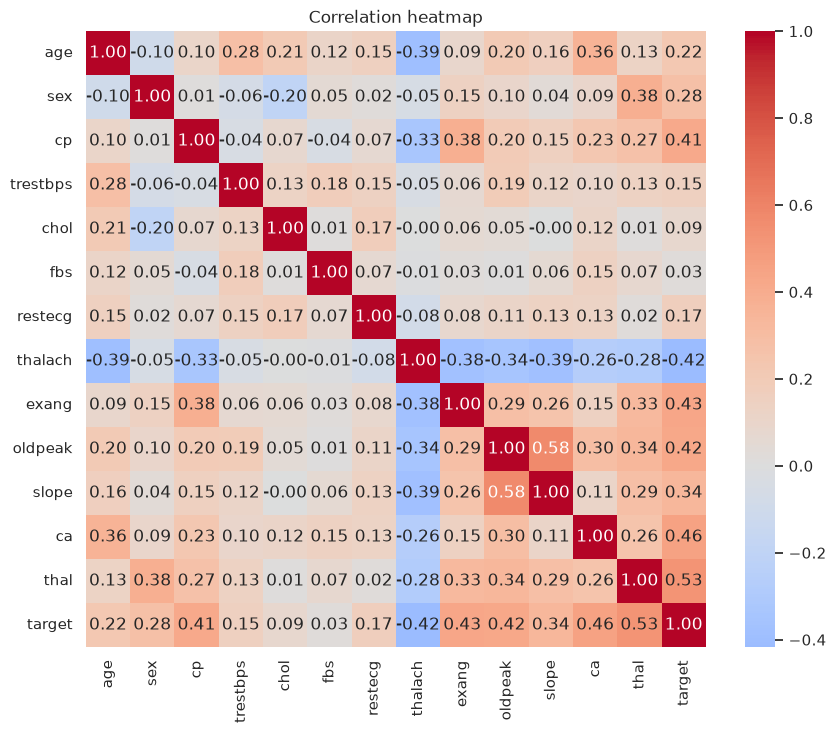

thal        0.526
ca          0.460
exang       0.432
oldpeak     0.425
thalach    -0.417
cp          0.414
slope       0.339
sex         0.277
age         0.223
restecg     0.169
trestbps    0.151
chol        0.085
fbs         0.025
Name: target, dtype: float64

In [4]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation heatmap')
plt.show()
corr['target'].drop('target').sort_values(key=abs, ascending=False).round(3)

`thal`, `ca`, `exang`, `oldpeak`, `thalach` and `cp` carry the strongest signal — mostly exercise-related measurements, which is clinically plausible.

## Key feature distributions by outcome

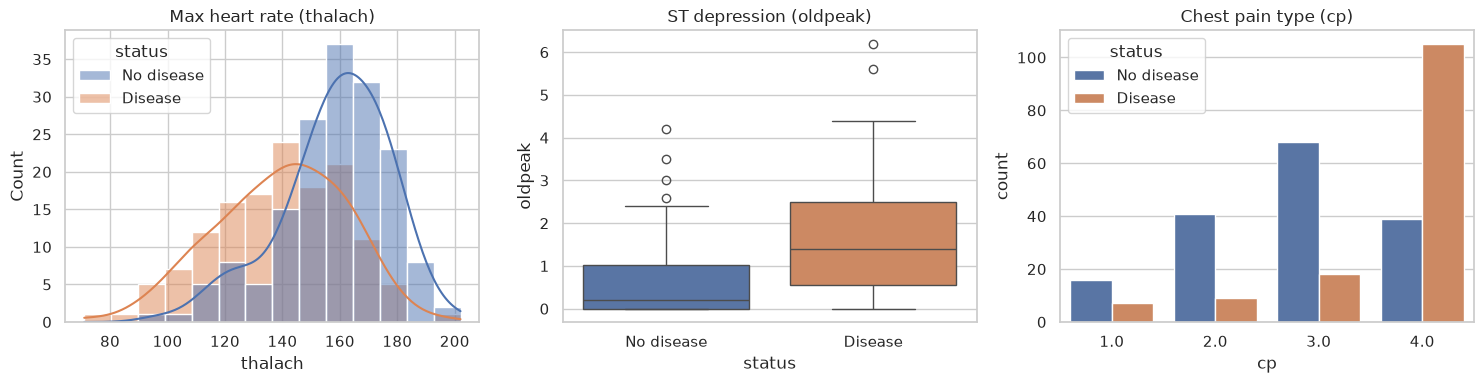

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labeled = df.assign(status=df['target'].map({0: 'No disease', 1: 'Disease'}))
sns.histplot(labeled, x='thalach', hue='status', kde=True, ax=axes[0])
axes[0].set_title('Max heart rate (thalach)')
sns.boxplot(labeled, x='status', y='oldpeak', hue='status', legend=False, ax=axes[1])
axes[1].set_title('ST depression (oldpeak)')
sns.countplot(labeled, x='cp', hue='status', ax=axes[2])
axes[2].set_title('Chest pain type (cp)')
plt.tight_layout()
plt.show()

## Modeling

Training/tuning is done by `python -m src.train`: three model families (logistic regression, random forest, gradient boosting) tuned with 5-fold stratified `GridSearchCV` on ROC-AUC, each run tracked in MLflow with metrics and plots. The best pipeline is exported to `models/model.joblib`. Below we load that artifact and use it.

In [6]:
import json
import joblib

model = joblib.load(root / 'models' / 'model.joblib')
metadata = json.loads((root / 'models' / 'metadata.json').read_text())
metadata

{'model_name': 'logistic_regression',
 'best_params': {'classifier__C': 0.1, 'classifier__class_weight': 'balanced'},
 'metrics': {'test_accuracy': 0.8852,
  'test_precision': 0.8387,
  'test_recall': 0.9286,
  'test_f1': 0.8814,
  'test_roc_auc': 0.9654,
  'cv_roc_auc_mean': 0.9028,
  'cv_roc_auc_std': 0.0169},
 'mlflow_run_id': '6e852303b7664724b9e79f5a6e0b88aa',
 'trained_at': '2026-07-11T17:03:58.030060+00:00',
 'sklearn_version': '1.9.0',
 'python_version': '3.14.5'}

## Inference on a new patient

Same contract as the API's `/predict`.

In [7]:
patient = pd.DataFrame([{
    'age': 57, 'sex': 1, 'cp': 4, 'trestbps': 140, 'chol': 241,
    'fbs': 0, 'restecg': 1, 'thalach': 123, 'exang': 1,
    'oldpeak': 0.2, 'slope': 2, 'ca': 0, 'thal': 7,
}]).astype('float64')

probability = model.predict_proba(patient)[0, 1]
print(f'P(heart disease) = {probability:.3f} -> '
      f"{'Heart disease' if probability >= 0.5 else 'No heart disease'}")

P(heart disease) = 0.841 -> Heart disease


## Sanity check: confusion matrix on the full dataset

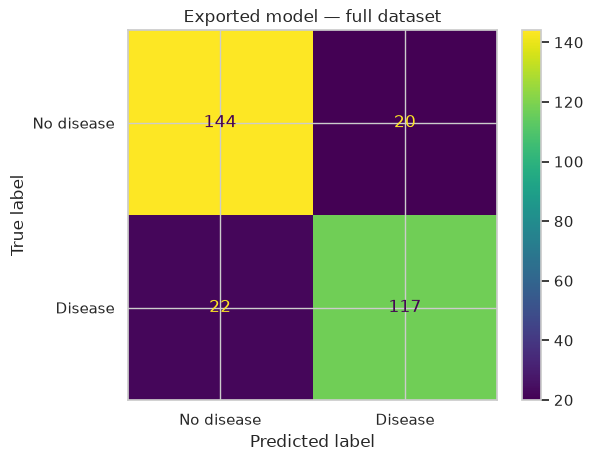

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

from src.data import split_features_target

X, y = split_features_target(df)
ConfusionMatrixDisplay.from_estimator(
    model, X, y, display_labels=['No disease', 'Disease'])
plt.title('Exported model — full dataset')
plt.show()